In [1]:
# Install required packages
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q accelerate bitsandbytes pillow scikit-learn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.0/502.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.0.0.dev0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 12.4 MB/s eta 0:00:00


In [2]:
# Import libraries
import os
import torch
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig
import matplotlib.pyplot as plt
import random
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

In [3]:
# Clone the PlantDoc dataset
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git

# Set up paths
dataset_path = "PlantDoc-Dataset"
test_path = os.path.join(dataset_path, "test")

Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 16.19 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.


In [4]:
# Create test dataset with ground truth labels
def create_test_dataset():
    data = {"image": [], "label": [], "class_name": []}

    if os.path.exists(test_path):
        for class_folder in os.listdir(test_path):
            class_path = os.path.join(test_path, class_folder)
            if os.path.isdir(class_path):
                for img_file in os.listdir(class_path):
                    if img_file.endswith(('.jpg', '.jpeg', '.png')):
                        img_path = os.path.join(class_path, img_file)
                        data["image"].append(img_path)
                        data["label"].append(class_folder)
                        data["class_name"].append(class_folder.replace('_', ' '))

    return data

In [5]:
# Load test dataset
test_data = create_test_dataset()
print(f"Total test images: {len(test_data['image'])}")

Total test images: 236


In [6]:
# Load BLIP-2 base model with 8-bit quantization
print("Loading BLIP-2 base model...")
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

quantization_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.float16
)

model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.float16
)

print("Model loaded successfully!")

Loading BLIP-2 base model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/10.0G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Model loaded successfully!


In [7]:
# Function to generate caption
def generate_caption(image_path, model, processor):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to("cuda", torch.float16)

    generated_ids = model.generate(**inputs, max_new_tokens=50)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

    return generated_text

In [8]:
# Select 15 random test samples
test_indices = random.sample(range(len(test_data['image'])), min(15, len(test_data['image'])))

# Store results for evaluation
results = {
    "image_path": [],
    "true_label": [],
    "predicted_caption": [],
    "match": []
}

In [9]:
# Test on 15 images
print("\nGenerating captions for 15 test images...")
for idx in test_indices:
    img_path = test_data['image'][idx]
    true_label = test_data['class_name'][idx]

    # Generate caption
    predicted_caption = generate_caption(img_path, model, processor)

    # Check if true label keywords are in predicted caption (simple matching)
    keywords = true_label.lower().split()
    match = any(keyword in predicted_caption.lower() for keyword in keywords)

    results["image_path"].append(img_path)
    results["true_label"].append(true_label)
    results["predicted_caption"].append(predicted_caption)
    results["match"].append(match)

    print(f"\n{len(results['image_path'])}/15 - True: {true_label}")
    print(f"Predicted: {predicted_caption}")
    print(f"Match: {'✓' if match else '✗'}")


Generating captions for 15 test images...

1/15 - True: Tomato Septoria leaf spot
Predicted: tomato leaf rust
Match: ✓

2/15 - True: Tomato Septoria leaf spot
Predicted: a tomato plant with brown spots on it
Match: ✓

3/15 - True: Corn leaf blight
Predicted: a leaf with brown spots
Match: ✓

4/15 - True: Potato leaf late blight
Predicted: a leaf with brown spots on it
Match: ✓

5/15 - True: Corn leaf blight
Predicted: a leaf with brown spots on it
Match: ✓

6/15 - True: Soyabean leaf
Predicted: a leaf with two leaves on it on a grid
Match: ✓

7/15 - True: Tomato leaf mosaic virus
Predicted: three leaves with yellow spots on them
Match: ✗

8/15 - True: Apple rust leaf
Predicted: a leaf with red dots on it is hanging from a tree
Match: ✓

9/15 - True: Corn leaf blight
Predicted: a leaf with white spots and brown spots
Match: ✓

10/15 - True: Strawberry leaf
Predicted: strawberry leaves stock photo image of
Match: ✓

11/15 - True: Corn leaf blight
Predicted: a person's hand is holding a 

In [10]:
# Calculate metrics
total_samples = len(results["match"])
correct_predictions = sum(results["match"])
accuracy = (correct_predictions / total_samples) * 100

print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)
print(f"Total Test Samples: {total_samples}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {total_samples - correct_predictions}")
print(f"Accuracy: {accuracy:.2f}%")
print("="*60)


EVALUATION METRICS
Total Test Samples: 15
Correct Predictions: 14
Incorrect Predictions: 1
Accuracy: 93.33%


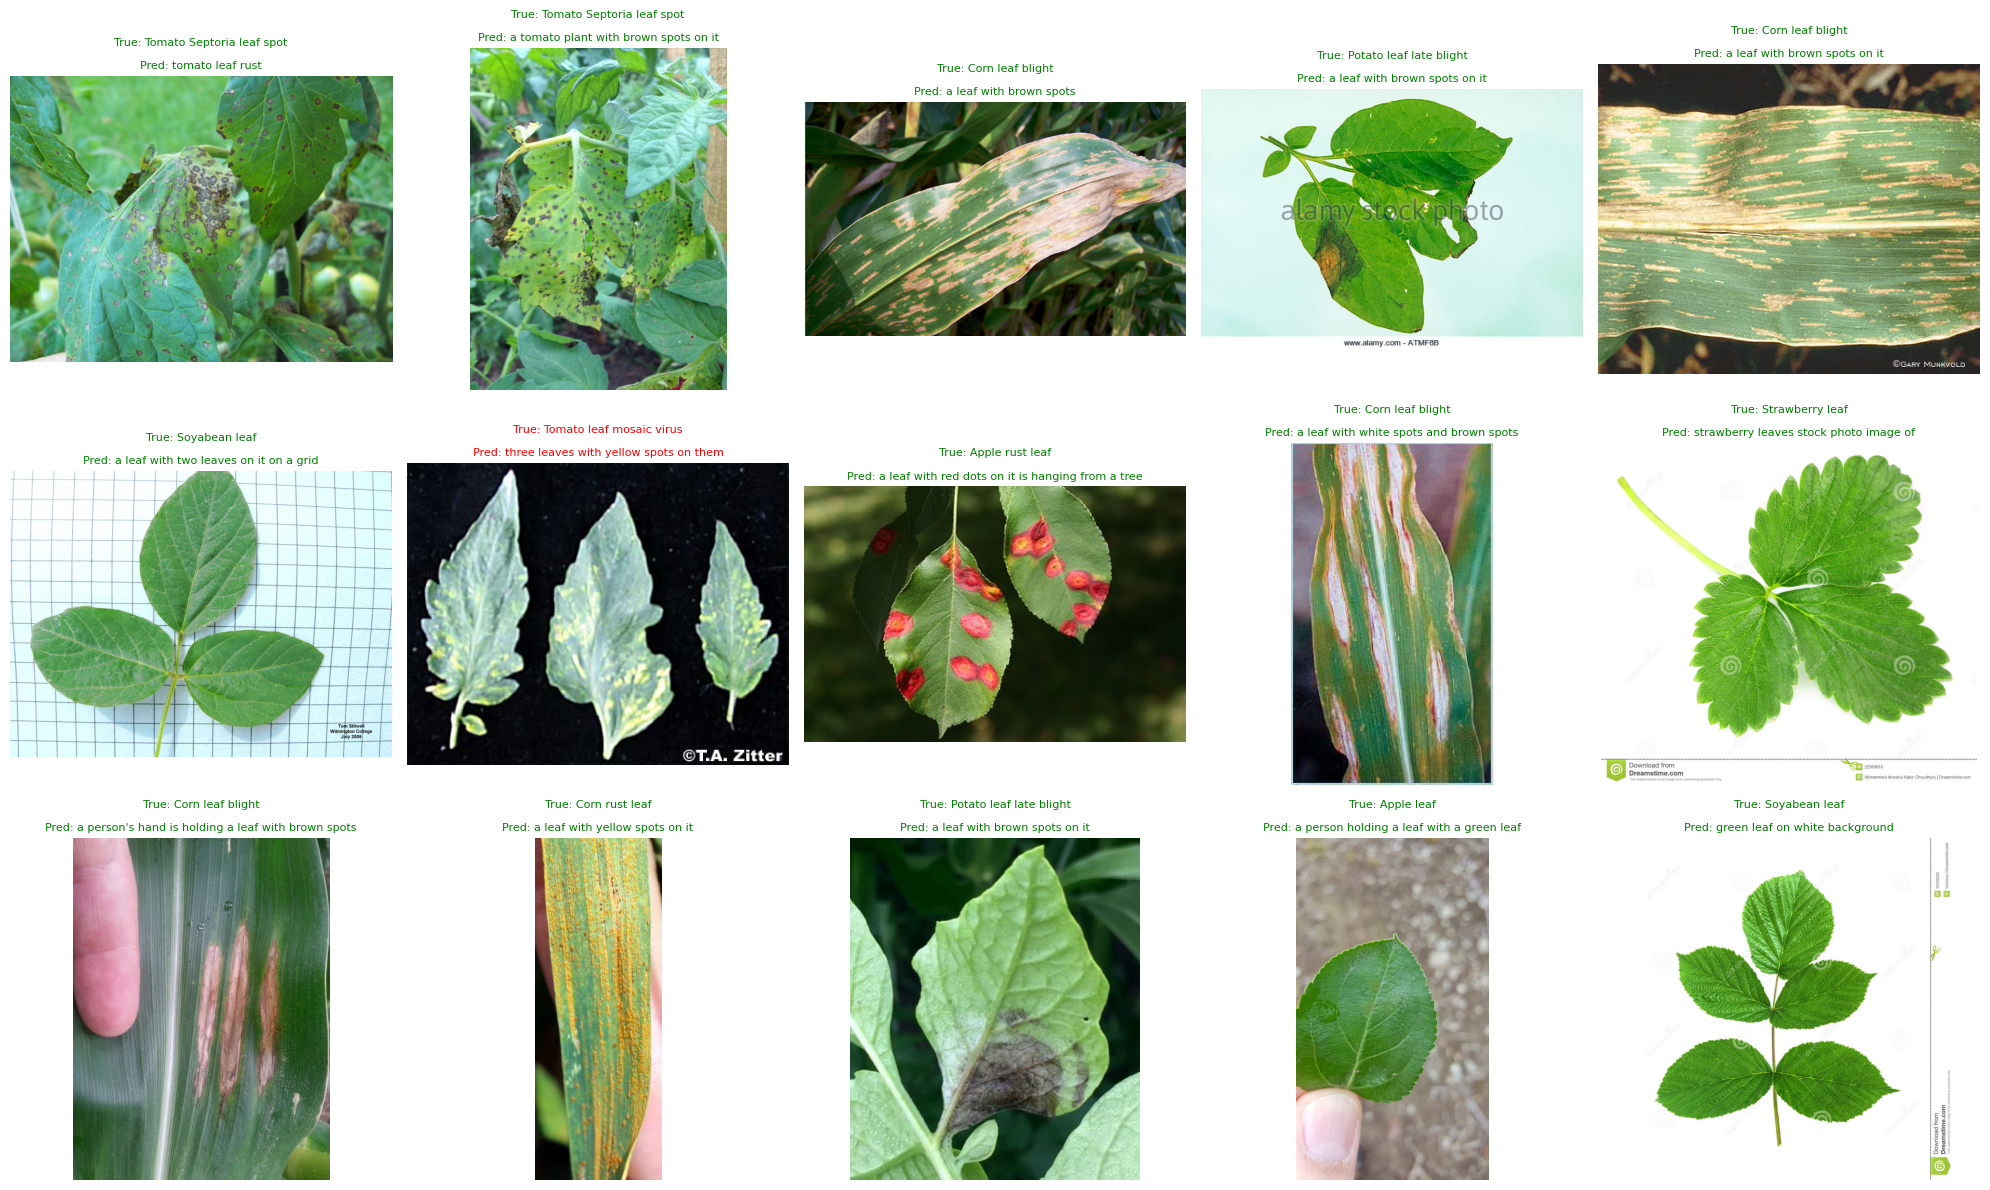


DETAILED RESULTS:
----------------------------------------------------------------------------------------------------
#   True Label                     Predicted Caption                                  Match
----------------------------------------------------------------------------------------------------
1   Tomato Septoria leaf spot      tomato leaf rust                                   ✓    
2   Tomato Septoria leaf spot      a tomato plant with brown spots on it              ✓    
3   Corn leaf blight               a leaf with brown spots                            ✓    
4   Potato leaf late blight        a leaf with brown spots on it                      ✓    
5   Corn leaf blight               a leaf with brown spots on it                      ✓    
6   Soyabean leaf                  a leaf with two leaves on it on a grid             ✓    
7   Tomato leaf mosaic virus       three leaves with yellow spots on them             ✗    
8   Apple rust leaf                a leaf w

In [11]:
# Visualize results
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for idx in range(15):
    img = Image.open(results["image_path"][idx])
    axes[idx].imshow(img)
    axes[idx].axis('off')

    # Color code: green for match, red for no match
    color = 'green' if results["match"][idx] else 'red'
    title = f"True: {results['true_label'][idx]}\n\nPred: {results['predicted_caption'][idx]}"
    axes[idx].set_title(title, fontsize=8, color=color, wrap=True)

plt.tight_layout()
plt.savefig('test_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed results table
print("\nDETAILED RESULTS:")
print("-" * 100)
print(f"{'#':<3} {'True Label':<30} {'Predicted Caption':<50} {'Match':<5}")
print("-" * 100)

for i in range(len(results["image_path"])):
    match_symbol = '✓' if results["match"][i] else '✗'
    print(f"{i+1:<3} {results['true_label'][i]:<30} {results['predicted_caption'][i]:<50} {match_symbol:<5}")

print("-" * 100)